In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras

In [ ]:
(X_train, y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()

In [ ]:
X_train.shape

(60000, 28, 28)

In [ ]:
y_train.shape

(60000,)

In [ ]:
X_test.shape

(10000, 28, 28)

In [ ]:
y_test.shape

(10000,)

In [ ]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [ ]:
y_test[:5]

array([7, 2, 1, 0, 4], dtype=uint8)

In [ ]:
class_names = [str(i) for i in range(10)]
print(f"Class names: {class_names}")

Class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


***index of the image***

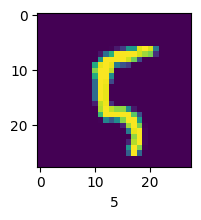

In [ ]:
def plot_sample(X, y, index):
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.xlabel(class_names[y[index]])
plot_sample(X_train, y_train, 100)

***this gor normalize the pixel value to 0 to 1 for This normalization step is crucial for training neural networks effectively,
as it can help the model converge faster and perform better.***

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
X_test

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [ ]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(f"X_train shape after reshape: {X_train.shape}")
print(f"X_test shape after reshape: {X_test.shape}")

X_train shape after reshape: (60000, 28, 28, 1)
X_test shape after reshape: (10000, 28, 28, 1)


In [ ]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
cnn.fit(X_train, y_train, epochs=4)

Epoch 1/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 24ms/step - accuracy: 0.9546 - loss: 0.1499
Epoch 2/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 26ms/step - accuracy: 0.9848 - loss: 0.0490
Epoch 3/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 26ms/step - accuracy: 0.9895 - loss: 0.0335
Epoch 4/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - accuracy: 0.9920 - loss: 0.0255


In [ ]:
cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9893 - loss: 0.0341


[0.034055497497320175, 0.989300012588501]

In [ ]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


array([[1.4859885e-06, 5.5635041e-07, 2.3268667e-06, 8.8991283e-06,
        2.4621218e-07, 1.0628932e-07, 2.6009067e-10, 9.9998218e-01,
        1.7318243e-06, 2.3210600e-06],
       [5.9505095e-07, 1.4237387e-06, 9.9999779e-01, 6.4887407e-09,
        6.2411845e-09, 5.2329798e-12, 1.6419389e-08, 3.2029581e-09,
        9.6928126e-08, 8.2786211e-10],
       [8.6527024e-07, 9.9990100e-01, 6.7345553e-07, 2.3025754e-08,
        4.5880985e-05, 1.8249691e-05, 2.4221106e-05, 5.9506569e-06,
        2.8969673e-06, 2.0663006e-07],
       [9.9909496e-01, 1.2795561e-09, 3.0848230e-07, 3.9938089e-07,
        7.4552112e-08, 3.1315079e-07, 8.5589569e-04, 3.1326814e-09,
        4.7796042e-05, 2.2746882e-07],
       [1.2719197e-08, 6.6083722e-08, 4.3113925e-08, 3.2924625e-09,
        9.9998993e-01, 1.3100889e-08, 4.5466475e-08, 5.5218252e-09,
        1.1035255e-06, 8.7120115e-06]], dtype=float32)

In [ ]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:10]

[np.int64(7),
 np.int64(2),
 np.int64(1),
 np.int64(0),
 np.int64(4),
 np.int64(1),
 np.int64(4),
 np.int64(9),
 np.int64(5),
 np.int64(9)]

In [ ]:
y_test[:2000]

array([7, 2, 1, ..., 3, 9, 5], dtype=uint8)

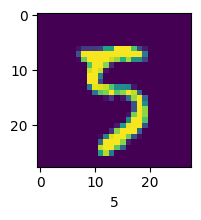

In [ ]:
plot_sample(X_test, y_test,1999)

In [ ]:
class_names[y_classes[3]]

'0'

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


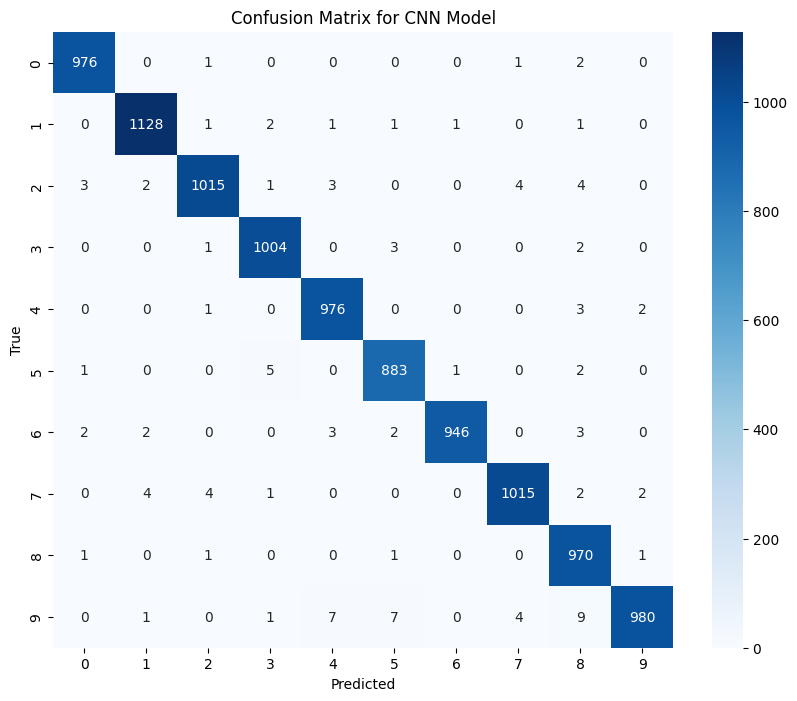

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions for the test set from the augmented model
y_pred_augmented = cnn.predict(X_test)
y_classes_augmented = [np.argmax(element) for element in y_pred_augmented]

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_classes_augmented)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for CNN Model')
plt.show()

In [ ]:
print("super")

super
